# L5 – Análisis de caso: Técnicas de reducción dimensional (Breast Cancer Wisconsin)

En este notebook resolvemos el análisis de caso usando el dataset **Breast Cancer Wisconsin (Diagnostic)** como análogo del dataset clínico de alta dimensionalidad.

Objetivos:

1. Cargar y explorar el dataset clínico.
2. Aplicar `StandardScaler`.
3. Aplicar **PCA**: elegir número óptimo de componentes, analizar varianza explicada y visualizar en 2D.
4. Aplicar **t-SNE**: probar parámetros y visualizar en 2D.
5. Comparar ambas técnicas y reflexionar sobre su uso en un pipeline de modelado.


In [1]:
# 1. Cargar librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42

## 1. Carga y análisis exploratorio inicial del dataset

Usamos `load_breast_cancer` de `sklearn`, que tiene 30 variables numéricas de características de células tumorales.


In [2]:
# 1.1 Cargar dataset Breast Cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = maligno, 1 = benigno

print('Dimensiones de X:', X.shape)
X.head()

Dimensiones de X: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# 1.2 Información general y valores nulos

print('Información del dataframe:')
print(X.info())
print('Total de valores nulos:', X.isnull().sum().sum())

Información del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14 

In [5]:
# 1.3 Estadísticos descriptivos

X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


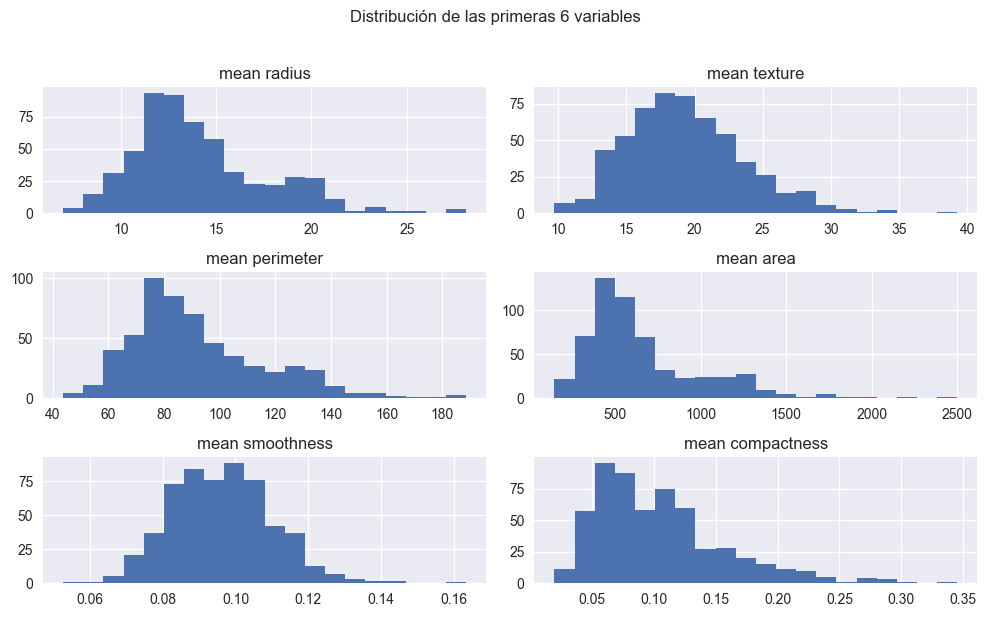

In [6]:
# 1.4 Histogramas de algunas variables

X.iloc[:, :6].hist(figsize=(10, 6), bins=20)
plt.suptitle('Distribución de las primeras 6 variables', y=1.02)
plt.tight_layout()
plt.show()

## 2. Aplicación de StandardScaler

Estandarizamos las variables para que todas tengan media 0 y desvío estándar 1, lo que evita que variables con escalas grandes dominen el análisis.


In [7]:
# 2.1 Escalar los datos

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Forma de X_scaled:', X_scaled.shape)
print('Media aprox (primeras 5 columnas):', X_scaled[:, :5].mean(axis=0))
print('Desvío aprox (primeras 5 columnas):', X_scaled[:, :5].std(axis=0))

Forma de X_scaled: (569, 30)
Media aprox (primeras 5 columnas): [-3.16286735e-15 -6.53060890e-15 -7.07889127e-16 -8.79983452e-16
  6.13217737e-15]
Desvío aprox (primeras 5 columnas): [1. 1. 1. 1. 1.]


## 3. PCA: elegir número óptimo de componentes

Primero ajustamos PCA con muchas componentes y miramos la **varianza explicada acumulada** para decidir cuántas retener.


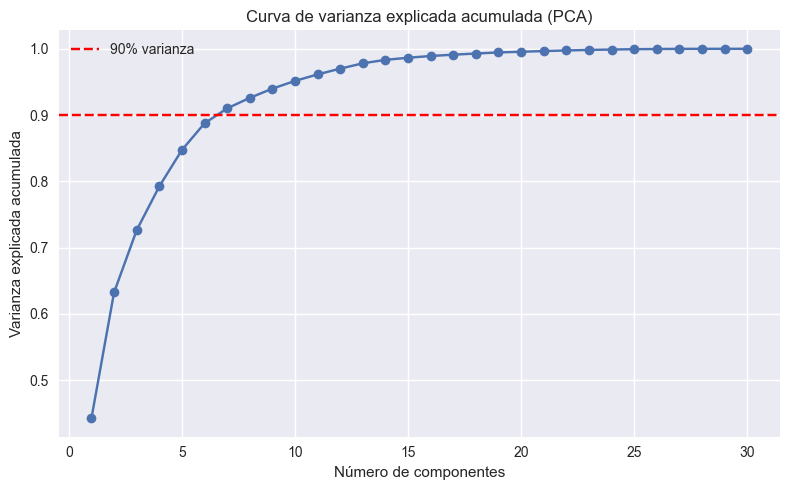

array([0.44272026, 0.63243208, 0.72636371, 0.79238506, 0.84734274,
       0.88758796, 0.9100953 , 0.92598254, 0.93987903, 0.95156881])

In [8]:
# 3.1 PCA inicial para todas las componentes

pca_full = PCA(n_components=X.shape[1], random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
var_acum = var_ratio.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Curva de varianza explicada acumulada (PCA)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

var_acum[:10]

### 3.2 Selección del número de componentes

A partir de la curva de varianza acumulada, elegimos el número mínimo de componentes que explica al menos ~90% de la varianza.

Para visualización 2D, de todos modos reduciremos luego a **2 componentes**, pero este análisis sirve para el pipeline de modelado.


In [9]:
# 3.3 PCA a 2 componentes para visualización

pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_scaled)

print('Varianza explicada por cada componente (2D):', pca_2.explained_variance_ratio_)
print('Varianza total explicada (2 componentes):', pca_2.explained_variance_ratio_.sum())

Varianza explicada por cada componente (2D): [0.44272026 0.18971182]
Varianza total explicada (2 componentes): 0.6324320765155946


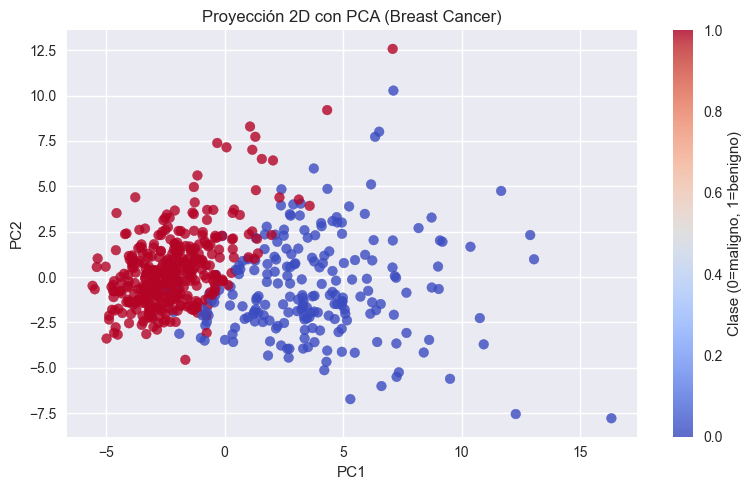

In [10]:
# 3.4 Visualización 2D de PCA

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.8
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección 2D con PCA (Breast Cancer)')
cbar = plt.colorbar(scatter)
cbar.set_label('Clase (0=maligno, 1=benigno)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. t-SNE: parámetros y visualización 2D

Aplicamos t-SNE sobre los datos escalados para obtener una proyección 2D no lineal que preserve vecindades.


In [11]:
# 4.1 t-SNE con una configuración base

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=RANDOM_STATE,
    init='pca'
)

X_tsne = tsne.fit_transform(X_scaled)

print('Forma de la proyección t-SNE:', X_tsne.shape)

Forma de la proyección t-SNE: (569, 2)


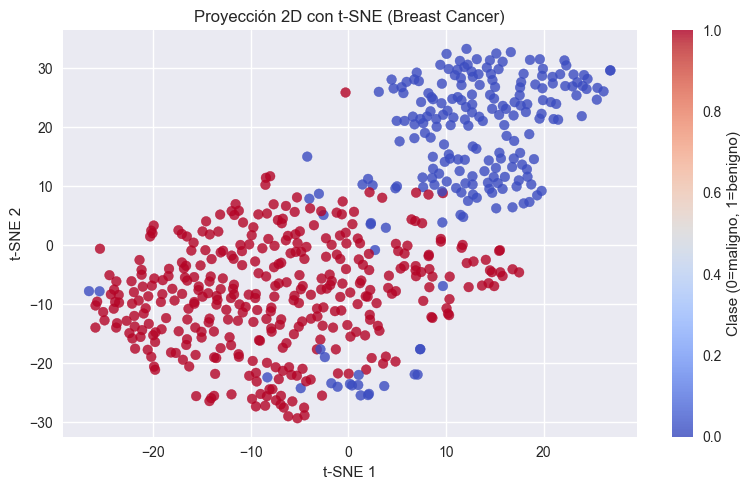

In [12]:
# 4.2 Visualización 2D de t-SNE

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.8
)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Proyección 2D con t-SNE (Breast Cancer)')
cbar = plt.colorbar(scatter)
cbar.set_label('Clase (0=maligno, 1=benigno)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.3 Efecto de distintos parámetros en t-SNE

Probamos distintas combinaciones de `perplexity` y `learning_rate` para ver cómo cambia la forma de los clústers.


C:\Users\yuri1\AppData\Local\Temp\ipykernel_11940\214118029.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


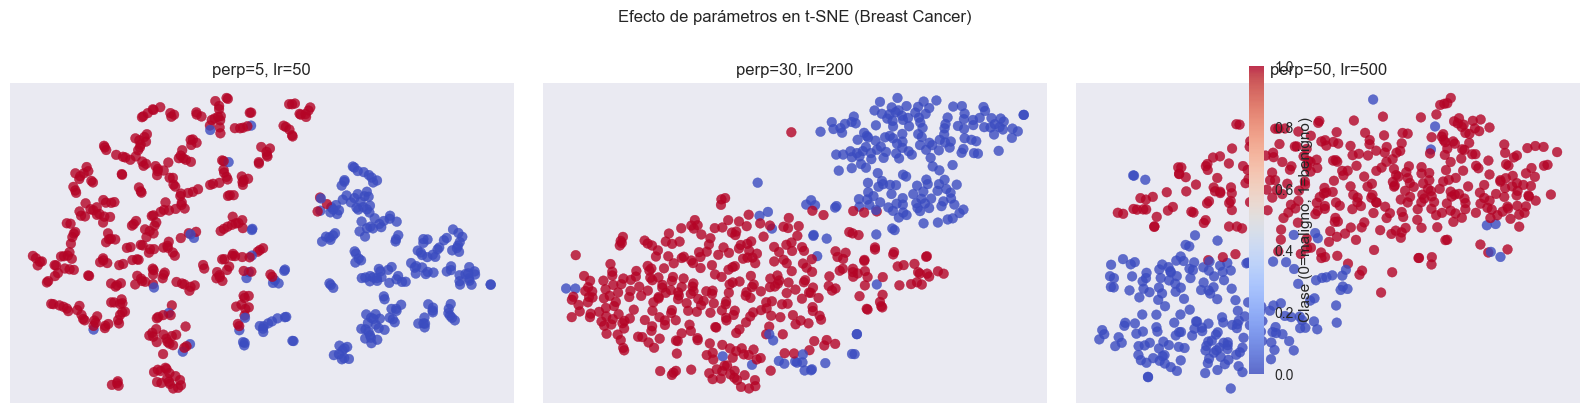

In [14]:
# 4.3 Probar otras configuraciones de t-SNE

configs = [
    {'perplexity': 5, 'learning_rate': 50},
    {'perplexity': 30, 'learning_rate': 200},
    {'perplexity': 50, 'learning_rate': 500},
]

fig, axes = plt.subplots(1, len(configs), figsize=(16, 4))

for ax, cfg in zip(axes, configs):
    tsne_cfg = TSNE(
        n_components=2,
        perplexity=cfg['perplexity'],
        learning_rate=cfg['learning_rate'],
        random_state=RANDOM_STATE,
        init='pca'
    )
    X_tsne_cfg = tsne_cfg.fit_transform(X_scaled)
    sc = ax.scatter(
        X_tsne_cfg[:, 0],
        X_tsne_cfg[:, 1],
        c=y,
        cmap='coolwarm',
        alpha=0.8
    )
    ax.set_title(f"perp={cfg['perplexity']}, lr={cfg['learning_rate']}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, ax=axes, label='Clase (0=maligno, 1=benigno)')
plt.suptitle('Efecto de parámetros en t-SNE (Breast Cancer)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Análisis comparativo PCA vs t-SNE



- ¿Cuál técnica permitió una mejor visualización de clústeres (benigno vs maligno)?
- ¿Qué método sería más útil como parte de un pipeline de modelado predictivo?

Una guía posible:

1. PCA suele ser mejor para **reducir dimensionalidad antes de modelos** (por ejemplo, quedarse con las primeras N componentes que explican ~90-95% de la varianza).
2. t-SNE suele ser mejor para **visualización exploratoria** y detección de clústers, pero no es ideal como paso fijo dentro de un pipeline supervisado porque:
   - Es más costoso computacionalmente.
   - No preserva distancias globales.
   - Los ejes no son interpretables y la transformación no es tan estable ante nuevos datos.


## 6. Notas para el informe técnico

En el informe PDF

1. **Introducción**: contexto clínico y problema de alta dimensionalidad.
2. **Metodología**: descripción breve de PCA y t-SNE y del preprocesamiento (StandardScaler).
3. **Resultados**:
   - Curva de varianza explicada y decisión del número de componentes para PCA.
   - Gráfico PCA 2D con clases benigno/maligno.
   - Gráfico t-SNE 2D con clases benigno/maligno y ejemplos de distintas configuraciones.
4. **Comparativa y recomendación**: discusión de cuándo usar PCA vs t-SNE en el pipeline.
5. **Reflexión personal**: qué aprendiste, dificultades (por ejemplo, elección de parámetros en t-SNE, interpretación de componentes, etc.).
